<!-- Notebook B banner -->
<div style="background:#E6F1FB;border-left:5px solid #185FA5;border-radius:0 12px 12px 0;
            padding:22px 28px 18px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            margin-bottom:4px">
  <p style="margin:0 0 4px;font-size:11px;font-weight:500;letter-spacing:.08em;
             color:#185FA5;text-transform:uppercase">
    2nd International Summer School on AI for Diabetes Management &nbsp;·&nbsp; University of Girona &nbsp;·&nbsp; Day 3 &nbsp;·&nbsp; 13:00–15:00
  </p>
  <h1 style="margin:6px 0 4px;font-size:24px;font-weight:600;color:#042C53;line-height:1.25">
    From Population Models to Personalized Digital Twins
  </h1>
  <p style="margin:0;font-size:16px;font-weight:400;color:#185FA5">
    Adapting AI Models to Individuals
  </p>
  <p style="margin:12px 0 0;font-size:13.5px;color:#0C447C;line-height:1.5;font-style:italic">
    Notebook B &nbsp;·&nbsp; transfer the population-pretrained decoder to one patient, fine-tune it, and evaluate distributional fidelity, trajectories, and therapy counterfactuals.
  </p>
  <p style="margin:14px 0 0;font-size:13px;color:#0C447C">
    <b>Notebook B</b> &nbsp;·&nbsp; Dr. Omer Mujahid &nbsp;·&nbsp; UdG–Dexcom Chair for Advancing AI in Clinical Practice
  </p>
</div>

# Personalized digital twins — Notebook B: personalize & evaluate

The population decoder was trained on the other patients and shipped as
`ad_best_decoder.h5`. Here you **transfer** those weights into a fresh model and
fine-tune on one held-out individual, then compare against a from-scratch baseline
and probe therapy counterfactuals.

This notebook imports the finished architecture from `twin_workshop2.py`, so it runs
even if Notebook A is incomplete.

## Why personalization?

Every person with Type 1 diabetes lives with a glucose regulation system shaped by their own physiology — their insulin sensitivity, carbohydrate absorption rate, and circadian patterns are uniquely theirs. A model trained on hundreds of patients learns the average of all of them, which is no one's individual reality.

This is the **personalization problem**: how do you adapt a model that has seen thousands of hours of population data to serve *this specific patient*, when you may only have a few days of their CGM record to work with?

The naive answer — train a new model from scratch on their data — fails because a few days of CGM data is far too little to constrain a deep generative model. Population pretraining changes the situation. The model arrives already knowing that insulin lowers glucose and carbohydrates raise it, that postprandial peaks tend to follow a characteristic shape, and that overnight fasting follows predictable dynamics. Fine-tuning on the individual then adjusts *how much* and *how fast* — the person-specific parameters — rather than learning the physiology from zero.

This notebook makes that argument concrete. You will train three variants of the same architecture on the same patient and measure whether the population prior actually helps.

## What you will do in this notebook

By the end of this session you will be able to:

1. **Transfer** pretrained decoder weights into a fresh model and **fine-tune** it on a single patient's CGM record, implementing the core steps of the personalization pipeline
2. **Compare** three model variants — population decoder, personalized decoder, and from-scratch decoder — using both clinical glycemic metrics and distributional distance measures
3. **Read** glucodensity plots and ECDF curves and explain what they reveal about generative model quality that RMSE alone does not
4. **Simulate** counterfactual therapy scenarios with the personalized twin: vary insulin dose and carbohydrate rescue, and measure the change in hypoglycemia risk across stochastic draws
5. **Articulate** why a distributional distance metric (Wasserstein) and a clinical bin-counting metric (Time-in-Range) can legitimately disagree — and why that disagreement is a feature of the evaluation design, not a flaw

> **Notebook A** covered the model architecture — encoder, decoder, VAE trainer, and the sign constraint. This notebook picks up from a pretrained population decoder (`ad_best_decoder.h5`) and focuses entirely on what happens after population training ends.

## Architecture recap

The model is a **conditional variational autoencoder (cVAE)**. During training the encoder compresses a window of CGM, insulin, and carb data into a low-dimensional latent vector $z$. The decoder reconstructs a glucose trajectory from $z$ conditioned on the same insulin and carb inputs. At inference time the encoder is discarded and the decoder is sampled stochastically — different draws of $z$ produce different plausible futures given the same inputs.

from IPython.display import display, HTML
<img src="architecture_diagram.svg" width="100%"/>

## The three variants you will build



The pretraining advantage is the core scientific claim of this line of work. A small positive Δ AD tells you the population prior helped; a negative Δ would mean the prior hurt this patient — an interesting result in its own right and worth discussing.

## Session roadmap

This notebook runs in sequence. Each section builds on the previous one — don't skip ahead.

| # | Section | What you do | ≈ time |
|---|---------|-------------|--------|
| **Setup** | Imports + verify | Load modules, confirm GPU/CPU | 3 min |
| **1** | Patient data + holdout | Pick a patient, inspect their CGM record, create the train/holdout split | 5 min |
| **2** | Personalize | Transfer population weights → fine-tune on the patient → observe best W1 | 15 min |
| **3** | Scratch baseline | Same architecture, no transfer → train from random init | 10 min |
| **4** | Distributional evaluation | Clinical panel + glucodensity + ECDF — compare all three variants | 15 min |
| **5** | Trajectory | Overlap-averaged prediction vs real CGM, hourly RMSE breakdown | 10 min |
| **6** | Counterfactual | Stress-test scan → identify risk window → intervene → measure risk reduction | 20 min |
| | **Discussion** | Three questions, open floor | 7 min |

> ⏱ **Pace yourself.** Sections 2 and 3 run training loops — expect about 2–3 minutes of compute each on Colab. Use that time to read the next section's header before the cell finishes.

---

## Setup

In [19]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"


import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

from twin_workshop import (
    LATENT_DIM, PRETRAINED, SAMPLES_PER_DAY, HOLDOUT_DAYS,
    list_patients, load_patient, make_windows, holdout_split,
    define_encoder, define_decoder, build_trainer, personalize,
    simulate, simulate_mc, to_mgdl, moving_avg_trajectory,
    state_metrics, distance_metrics, glycemic_metrics,
    glucodensity, glucodensity_distance, verify_setup
)
verify_setup()

Workshop setup check
----------------------------------------
  TensorFlow 2.10.0  | legacy Keras: True
  data folder: 1 patients found (csv)


D:\python environments\environments\tf210\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


  pretrained decoder loads + forward pass OK
----------------------------------------
READY


True

In [2]:
# @title Model hyperparameters — quick reference
# ── Reference card — runs automatically, nothing to fill in ───────────────────
from IPython.display import HTML

def _row(key, val, accent=False):
    color = "#185FA5" if accent else "#2C2C2A"
    return (f'<div class="hp-row"><span class="hp-key">{key}</span>'
            f'<span class="hp-val" style="color:{color}">{val}</span></div>')

_html = f"""
<style>
  .hp-wrap{{font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;margin:8px 0 20px}}
  .hp-title{{font-size:14px;font-weight:500;color:#2C2C2A;margin:0 0 10px}}
  .hp-grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(175px,1fr));gap:10px}}
  .hp-card{{background:#F8F7F3;border:0.5px solid #D3D1C7;border-radius:8px;padding:12px 14px}}
  .hp-section{{font-size:10px;font-weight:500;color:#888780;letter-spacing:.07em;
               text-transform:uppercase;margin:0 0 8px}}
  .hp-row{{display:flex;justify-content:space-between;align-items:baseline;
           font-size:12.5px;padding:3px 0;border-bottom:0.5px solid #E8E6DF}}
  .hp-row:last-child{{border-bottom:none}}
  .hp-key{{color:#5F5E5A}}
  .hp-val{{font-family:'SF Mono','Fira Mono',monospace;font-weight:500;color:#2C2C2A}}
</style>
<div class="hp-wrap">
  <p class="hp-title">Model hyperparameters — quick reference</p>
  <div class="hp-grid">
    <div class="hp-card">
      <p class="hp-section">Architecture</p>
      {_row("Latent dim", LATENT_DIM)}
      {_row("Encoder LSTM width", 100)}
      {_row("Decoder hidden", 64)}
      {_row("Horizon H", "18 samples (90 min)")}
      {_row("Cell type", "LSTM")}
    </div>
    <div class="hp-card">
      <p class="hp-section">Training</p>
      {_row("KL weight", "3 × 10⁻³")}
      {_row("Epochs (fine-tune)", 20)}
      {_row("Batch size", 32)}
      {_row("Early-stop patience", 3)}
      {_row("Monitor", "Wasserstein (W1)")}
    </div>
    <div class="hp-card">
      <p class="hp-section">Data</p>
      {_row("Patients in cohort", 59)}
      {_row("CGM interval", "5 min")}
      {_row("Samples / day", SAMPLES_PER_DAY)}
      {_row("Holdout", f"{HOLDOUT_DAYS} days")}
      {_row("Columns", "BG, PI, RA")}
    </div>
    <div class="hp-card">
      <p class="hp-section">Sign constraint</p>
      {_row("Insulin weight", "≤ −ε", True)}
      {_row("Carb weight", "≥ +ε", True)}
      {_row("Min gain ε", "0.3 mg/dL")}
      {_row("Enforced via", "softplus")}
    </div>
    <div class="hp-card">
      <p class="hp-section">Counterfactual scan</p>
      {_row("Insulin stress factor", "× 1.40")}
      {_row("MC draws per window", 10)}
      {_row("Window size", "15 samples (75 min)")}
      {_row("Scan step", "6 samples (30 min)")}
      {_row("Risk threshold", "25 %")}
    </div>
    <div class="hp-card">
      <p class="hp-section">Glycemic ranges</p>
      {_row("Hypoglycemia", "< 70 mg/dL", True)}
      {_row("Tight TIR", "70–140 mg/dL", True)}
      {_row("Broad TIR", "70–180 mg/dL", True)}
      {_row("TAR", "> 180 mg/dL")}
      {_row("Hypo min consecutive", "3 samples (15 min)")}
    </div>
  </div>
</div>"""

HTML(_html)

## 1 · Patient data + holdout

In [22]:
PATIENT_ID = list_patients("csv")[0]
df = load_patient(PATIENT_ID, fmt="csv")
insulin_arr, carbs_arr, bg_arr, scalers = make_windows(df)
(train_ins, train_carbs, train_bg), (holdout_ins, holdout_carbs, holdout_bg) = \
    holdout_split(insulin_arr, carbs_arr, bg_arr)
print(f"{PATIENT_ID} | train {train_bg.shape[0]} | holdout {holdout_bg.shape[0]}")

patient_18 | train 6930 | holdout 864


## 2 · Personalize — transfer then fine-tune

Start from a **fresh** encoder and decoder, copy the population decoder's weights into the decoder (the encoder is learned per patient), then fine-tune.

<div style="border-left:4px solid #185FA5;background:#E6F1FB;padding:14px 18px;border-radius:0 8px 8px 0">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:6px">
<span style="background:#185FA5;color:#E6F1FB;font-size:11px;font-weight:500;letter-spacing:.04em;padding:3px 9px;border-radius:20px">BLANK 5</span>
<span style="color:#042C53;font-size:15px;font-weight:500">Fresh model</span>
<span style="margin-left:auto;color:#185FA5;font-size:12px">Notebook B · personalize</span>
</div>
<p style="margin:6px 0 0;color:#06325a;font-size:13.5px;line-height:1.6">Personalization starts from a clean architecture. Build a new encoder and a new decoder using the imported <code style="background:#e8e6dd;padding:1px 5px;border-radius:4px">define_encoder</code> and <code style="background:#e8e6dd;padding:1px 5px;border-radius:4px">define_decoder</code>.</p>
<p style="margin:8px 0 0;color:#185FA5;font-size:13.5px"><b style="font-weight:500">Your task:</b> instantiate <code style="background:#e8e6dd;padding:1px 5px;border-radius:4px">encoder</code> and <code style="background:#e8e6dd;padding:1px 5px;border-radius:4px">decoder</code> from the factory functions.</p>
</div>

<div style="border-left:4px solid #185FA5;background:#E6F1FB;padding:14px 18px;border-radius:0 8px 8px 0">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:6px">
<span style="background:#185FA5;color:#E6F1FB;font-size:11px;font-weight:500;letter-spacing:.04em;padding:3px 9px;border-radius:20px">BLANK 6</span>
<span style="color:#042C53;font-size:15px;font-weight:500">Transfer the pretrained decoder</span>
<span style="margin-left:auto;color:#185FA5;font-size:12px">Notebook B · personalize</span>
</div>
<p style="margin:6px 0 0;color:#06325a;font-size:13.5px;line-height:1.6">The shipped <code style="background:#e8e6dd;padding:1px 5px;border-radius:4px">ad_best_decoder.h5</code> holds weights trained on the other patients. Copy them into your fresh decoder so fine-tuning starts from the population prior, not random init.</p>
<p style="margin:8px 0 0;color:#185FA5;font-size:13.5px"><b style="font-weight:500">Your task:</b> copy the loaded model's weights into <code style="background:#e8e6dd;padding:1px 5px;border-radius:4px">decoder</code>.</p>
</div>

In [23]:
# ---- BLANK 5 ----
encoder = ___                              # hint: define_encoder()
decoder = ___                              # hint: define_decoder()
vae = build_trainer(encoder, decoder)

# ---- BLANK 6 ----
loaded = load_model(PRETRAINED, compile=False)
decoder.___(loaded.get_weights()) 
print("Decoder weights transferred; encoder stays fresh.")

best_w1 = personalize(vae, encoder, decoder, (train_ins, train_carbs, train_bg),
                      n_epochs=20, batch_size=32, use_early_stopping=True, patience=3)
print(f"[PERSONALIZED] best W1 = {best_w1:.4f}")

D:\python environments\environments\tf210\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


Decoder weights transferred; encoder stays fresh.
195/195 [==============================] - 14s 37ms/step - loss: 0.6974 - recon: 0.0492 - kl: 0.0240 - mono: 12.9636
Epoch 1/20 | loss=0.684216 recon=0.035714 kl=0.099666 mono=12.964075
[W1] epoch 1: 0.057781 (best: inf)
195/195 [==============================] - 7s 34ms/step - loss: 0.6801 - recon: 0.0305 - kl: 0.4128 - mono: 12.9658
Epoch 2/20 | loss=0.680341 recon=0.029140 kl=1.051318 mono=12.960943
[W1] epoch 2: 0.095283 (best: 0.057781)
195/195 [==============================] - 7s 35ms/step - loss: 0.6718 - recon: 0.0194 - kl: 1.3704 - mono: 12.9663
Epoch 3/20 | loss=0.665770 recon=0.014960 kl=0.837707 mono=12.965930
[W1] epoch 3: 0.131234 (best: 0.057781)
195/195 [==============================] - 7s 36ms/step - loss: 0.6647 - recon: 0.0114 - kl: 1.6355 - mono: 12.9671
Epoch 4/20 | loss=0.665226 recon=0.012497 kl=1.548148 mono=12.961695
[W1] epoch 4: 0.109064 (best: 0.057781)
195/195 [==============================] - 7s 37ms/ste

## 3 · From-scratch baseline

Same architecture, **no** transfer — trained on this patient from random init. The gap to the personalized model is what population pretraining buys you.

<div style="border-left:4px solid #185FA5;background:#E6F1FB;padding:14px 18px;border-radius:0 8px 8px 0">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:6px">
<span style="background:#185FA5;color:#E6F1FB;font-size:11px;font-weight:500;letter-spacing:.04em;padding:3px 9px;border-radius:20px">BLANK 7</span>
<span style="color:#042C53;font-size:15px;font-weight:500">Scratch baseline</span>
<span style="margin-left:auto;color:#185FA5;font-size:12px">Notebook B · evaluate</span>
</div>
<p style="margin:6px 0 0;color:#06325a;font-size:13.5px;line-height:1.6">Build a fresh model exactly like above but do not transfer any weights. Train it with <code style="background:#e8e6dd;padding:1px 5px;border-radius:4px">personalize</code> on the same patient data.</p>
<p style="margin:8px 0 0;color:#185FA5;font-size:13.5px"><b style="font-weight:500">Your task:</b> create <code style="background:#e8e6dd;padding:1px 5px;border-radius:4px">decoder_scratch</code> with no <code style="background:#e8e6dd;padding:1px 5px;border-radius:4px">set_weights</code> call, then train.</p>
</div>

In [24]:
import tensorflow as tf
tf.keras.backend.clear_session()

encoder_scratch = define_encoder()
# ---- BLANK 7 ----
decoder_scratch = ___          # hint: define_decoder(), and DON'T transfer weights
vae_scratch = build_trainer(encoder_scratch, decoder_scratch)

best_w1_scratch = personalize(vae_scratch, encoder_scratch, decoder_scratch,
                              (train_ins, train_carbs, train_bg),
                              n_epochs=20, batch_size=32, patience=3)
print(f"[SCRATCH]      best W1 = {best_w1_scratch:.4f}")
print(f"[PERSONALIZED] best W1 = {best_w1:.4f}")
print(f"[Δ] pretraining advantage = {best_w1_scratch - best_w1:+.4f} (lower W1 better)")

195/195 [==============================] - 15s 36ms/step - loss: 0.9475 - recon: 0.3010 - kl: 0.2130 - mono: 12.9173
Epoch 1/20 | loss=0.727917 recon=0.077329 kl=1.794902 mono=12.904049
[W1] epoch 1: 0.369961 (best: inf)
195/195 [==============================] - 7s 35ms/step - loss: 0.7037 - recon: 0.0480 - kl: 3.2224 - mono: 12.9220
Epoch 2/20 | loss=0.710452 recon=0.054657 kl=3.303351 mono=12.917700
[W1] epoch 2: 0.262862 (best: 0.369961)
195/195 [==============================] - 7s 36ms/step - loss: 0.6887 - recon: 0.0328 - kl: 3.2332 - mono: 12.9242
Epoch 3/20 | loss=0.689165 recon=0.031511 kl=3.688816 mono=12.931753
[W1] epoch 3: 0.224850 (best: 0.262862)
195/195 [==============================] - 7s 34ms/step - loss: 0.6828 - recon: 0.0279 - kl: 2.8755 - mono: 12.9258
Epoch 4/20 | loss=0.677165 recon=0.024457 kl=2.040819 mono=12.931692
[W1] epoch 4: 0.203143 (best: 0.224850)
195/195 [==============================] - 7s 35ms/step - loss: 0.6783 - recon: 0.0240 - kl: 2.6071 - mo

<div style="border-left:4px solid #D85A30;background:#FDF0EA;padding:14px 18px;border-radius:0 8px 8px 0">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:6px">
<span style="background:#D85A30;color:#FDF0EA;font-size:11px;font-weight:500;letter-spacing:.04em;padding:3px 9px;border-radius:20px">PREDICT</span>
<span style="color:#5a2a12;font-size:15px;font-weight:500">Sweep or upset?</span>
<span style="margin-left:auto;color:#D85A30;font-size:12px">Notebook B · evaluate</span>
</div>
<p style="margin:6px 0 0;color:#6b3418;font-size:13.5px;line-height:1.6">Wasserstein, Euclidean, and glucodensity-L2 all score a model by how close its <i>entire</i> generated distribution sits to the real one. TIR, GMI, and CV don't care about the whole distribution — they only care whether BG mass sits on the right side of a few fixed thresholds (70, 180 mg/dL). A model can pull its overall distribution closer to real and <i>still</i> shift mass across one of those lines the wrong way.</p>
<p style="margin:8px 0 0;color:#6b3418;font-size:13.5px;line-height:1.6">Look at the full table below. Does Personalized sweep every single column, or does it lose at least one to Scratch or even Population?</p>
<p style="margin:8px 0 0;color:#D85A30;font-size:13.5px"><b style="font-weight:500">Your bet:</b> if you think there's an upset, name the metric before you run the cell.</p>
</div>

## 4 · Distributional evaluation — Real vs Population vs Personalized vs Scratch

The twin is stochastic, so we compare **distributions** over the held-out days, not curves. Absolute metrics get a value for all three; distance-to-real metrics only exist for the generated models.

D:\python environments\environments\tf210\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


                 Real (patient)  Population  Personalized  Scratch
Mean BG                 139.821     102.040       140.834  152.042
GMI %                     6.655       5.751         6.679    6.947
CV %                     33.926      72.400        30.373   52.852
TBR <54                   0.486      28.299         0.000    5.041
TBR 54-69                 3.738      15.085         0.373    7.639
TIR 70-180               76.741      42.368        83.963   55.601
TITR 70-140              49.834      32.356        61.233   38.612
TAR 180-250              16.308       8.443        12.937   18.403
TAR >250                  2.727       5.806         2.726   13.317
Quantile MAE                NaN      47.145        13.664   34.045
Wasserstein                 NaN      44.700         8.980   30.445
Tailmass L1                 NaN       0.861         0.144    0.478
ACF RMSE                    NaN       0.124         0.120    0.093
Glucodensity W2             NaN      49.184        13.469   43

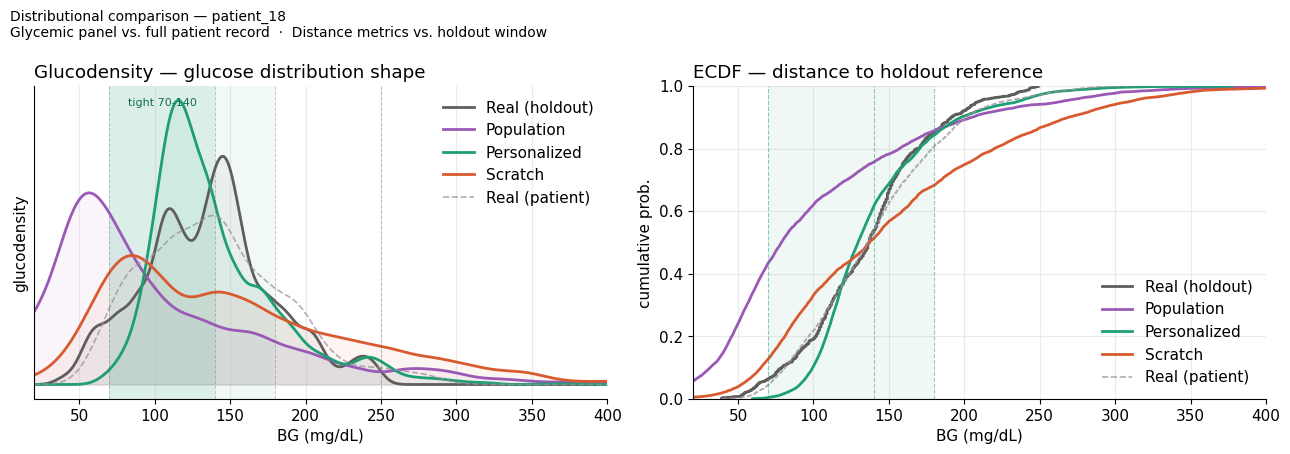

In [50]:
# ── Population decoder (before personalization) ───────────────────────────────
decoder_pop = load_model(PRETRAINED, compile=False)

# ── Full patient BG — glycemic phenotype reference ───────────────────────────
G_patient = df["BG"].values.astype(float)

# ── Holdout window — distributional distance reference ────────────────────────
G_real    = to_mgdl(holdout_bg,  scalers["bg"])
G_gen_pop = simulate(decoder_pop,     holdout_ins, holdout_carbs, scalers["bg"], seed=0)
G_gen_p   = simulate(decoder,         holdout_ins, holdout_carbs, scalers["bg"], seed=0)
G_gen_s   = simulate(decoder_scratch, holdout_ins, holdout_carbs, scalers["bg"], seed=0)
n = min(len(G_real), len(G_gen_pop), len(G_gen_p), len(G_gen_s))
G_real, G_gen_pop, G_gen_p, G_gen_s = G_real[:n], G_gen_pop[:n], G_gen_p[:n], G_gen_s[:n]

# ── Clinical glycemic panel ───────────────────────────────────────────────────
glyc = pd.DataFrame({
    "Real (patient)": glycemic_metrics(G_patient),
    "Population":     glycemic_metrics(G_gen_pop),
    "Personalized":   glycemic_metrics(G_gen_p),
    "Scratch":        glycemic_metrics(G_gen_s),
})

# ── Distribution distance metrics (holdout window as reference) ───────────────
all_dist = lambda Gr, Gg: {**distance_metrics(Gr, Gg), **glucodensity_distance(Gr, Gg)}
dist = pd.DataFrame({
    "Population":   all_dist(G_real, G_gen_pop),
    "Personalized": all_dist(G_real, G_gen_p),
    "Scratch":      all_dist(G_real, G_gen_s),
})
dist.insert(0, "Real (patient)", np.nan)

results = pd.concat([glyc, dist]).round(3)
print(results.to_string())

# ── Glucodensity (left) + ECDF (right) ───────────────────────────────────────
COL = {
    "Real (holdout)": "#5F5E5A",
    "Real (patient)": "#9B8EA0",
    "Population":     "#9B59B6",
    "Personalized":   "#1D9E75",
    "Scratch":        "#D85A30",
}
series = {
    "Real (holdout)": G_real,
    "Population":     G_gen_pop,
    "Personalized":   G_gen_p,
    "Scratch":        G_gen_s,
}

grid = np.linspace(20, 400, 400)
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "font.size": 11,
})
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Glucodensity panel ---
for nm, G in series.items():
    gx, gd = glucodensity(G, grid)
    axL.plot(gx, gd, color=COL[nm], lw=2, label=nm)
    axL.fill_between(gx, gd, color=COL[nm], alpha=.06)

gx_p, gd_p = glucodensity(G_patient, grid)
axL.plot(gx_p, gd_p, color=COL["Real (patient)"], lw=1.2, ls="--",
         label="Real (patient)", alpha=.75)

axL.axvspan(70, 180, color="#1D9E75", alpha=.06, lw=0)
axL.axvspan(70, 140, color="#1D9E75", alpha=.10, lw=0)
for q in (70, 140, 180, 250):
    axL.axvline(q, color="#5F5E5A", lw=.7, ls="--", alpha=.35)
axL.text(105, axL.get_ylim()[1] * 0.96, "tight 70-140",
         ha="center", va="top", fontsize=8, color="#0F6E56")
axL.set_xlim(20, 400); axL.set_yticks([])
axL.set_xlabel("BG (mg/dL)"); axL.set_ylabel("glucodensity")
axL.set_title("Glucodensity — glucose distribution shape", loc="left")
axL.legend(frameon=False)

# --- ECDF panel ---
def ecdf(a):
    x = np.sort(a.reshape(-1))
    return x, np.arange(1, len(x) + 1) / len(x)

for nm, G in series.items():
    x, y = ecdf(G); axR.plot(x, y, color=COL[nm], lw=2, label=nm)

xp, yp = ecdf(G_patient)
axR.plot(xp, yp, color=COL["Real (patient)"], lw=1.2, ls="--",
         label="Real (patient)", alpha=.75)

axR.axvspan(70, 180, color="#1D9E75", alpha=.07, lw=0)
for q in (70, 140, 180):
    axR.axvline(q, color="#1D9E75", lw=.8, ls="--", alpha=.5)
axR.set_xlim(20, 400); axR.set_ylim(0, 1)
axR.set_xlabel("BG (mg/dL)"); axR.set_ylabel("cumulative prob.")
axR.set_title("ECDF — distance to holdout reference", loc="left")
axR.legend(frameon=False, loc="lower right")

fig.suptitle(
    f"Distributional comparison — {PATIENT_ID}\n"
    f"Glycemic panel vs. full patient record  ·  Distance metrics vs. holdout window",
    x=.01, ha="left", fontsize=10,
)
plt.tight_layout(); plt.show()

In [26]:
from twin_workshop import distance_metrics

# Reuse a slice of the *training* data as a second reference window
G_train_ref = to_mgdl(train_bg[-holdout_bg.shape[0]:], scalers["bg"])
G_gen_p_train = simulate(decoder,         train_ins[-holdout_ins.shape[0]:], train_carbs[-holdout_carbs.shape[0]:], scalers["bg"], seed=0)
G_gen_s_train = simulate(decoder_scratch, train_ins[-holdout_ins.shape[0]:], train_carbs[-holdout_carbs.shape[0]:], scalers["bg"], seed=0)

gap = pd.DataFrame({
    "Personalized": {
        "W1 (train)":   distance_metrics(G_train_ref, G_gen_p_train)["Wasserstein"],
        "W1 (holdout)": distance_metrics(G_real,       G_gen_p)["Wasserstein"],
    },
    "Scratch": {
        "W1 (train)":   distance_metrics(G_train_ref, G_gen_s_train)["Wasserstein"],
        "W1 (holdout)": distance_metrics(G_real,       G_gen_s)["Wasserstein"],
    },
})
gap.loc["train→holdout gap"] = gap.loc["W1 (holdout)"] - gap.loc["W1 (train)"]
gap

,Personalized,Scratch
W1 (train),14.624091,22.780958
W1 (holdout),8.980340,30.444537
train→holdout gap,-5.643751,7.663579


<!-- QUESTION 2 — before cell 23 (§5, trajectory) -->
<div style="border-left:4px solid #D85A30;background:#FDF0EA;padding:14px 18px;border-radius:0 8px 8px 0">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:6px">
<span style="background:#D85A30;color:#FDF0EA;font-size:11px;font-weight:500;letter-spacing:.04em;padding:3px 9px;border-radius:20px">PREDICT</span>
<span style="color:#5a2a12;font-size:15px;font-weight:500">Does a pooled win guarantee a win on any single day?</span>
<span style="margin-left:auto;color:#D85A30;font-size:12px">Notebook B · trajectory</span>
</div>
<p style="margin:6px 0 0;color:#6b3418;font-size:13.5px;line-height:1.6">Every metric in Section 4 was computed by pooling all samples across the holdout window together — it's a summary over many days, not a claim about any one of them. A model can win that pooled comparison by being solidly better on most days while still losing on some individual day you happen to pick.</p>
<p style="margin:8px 0 0;color:#6b3418;font-size:13.5px;line-height:1.6">This section shows you exactly one specific holdout day.</p>
<p style="margin:8px 0 0;color:#D85A30;font-size:13.5px"><b style="font-weight:500">Your bet:</b> do you expect Personalized to visibly beat Scratch on this particular day — or would a tie, or even a loss, still be perfectly consistent with everything you saw in Section 4?</p>
</div>

## 5 · Representative Patient Trajectory — Population vs Personalized vs Scratch

Rather than compare distributions only, we now plot a concrete time-series:
the same real insulin and carb inputs are fed to the population decoder
(weights before fine-tuning), the personalized decoder, and the scratch
decoder. Predictions are overlap-averaged across all horizon windows
(**the same method used in the paper**), producing a single smooth curve.


D:\python environments\environments\tf210\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(
D:\Post doc\Summer School_AI in diabetes\workshop-transfer-learning\twin_workshop.py:428: RuntimeWarning: Mean of empty slice
  return np.nanmean(mat, axis=0)                             # (n + H - 1,)
D:\Post doc\Summer School_AI in diabetes\workshop-transfer-learning\twin_workshop.py:428: RuntimeWarning: Mean of empty slice
  return np.nanmean(mat, axis=0)                             # (n + H - 1,)
D:\Post doc\Summer School_AI in diabetes\workshop-transfer-learning\twin_workshop.py:428: RuntimeWarning: Mean of empty slice
  return np.nanmean(mat, axis=0)                        

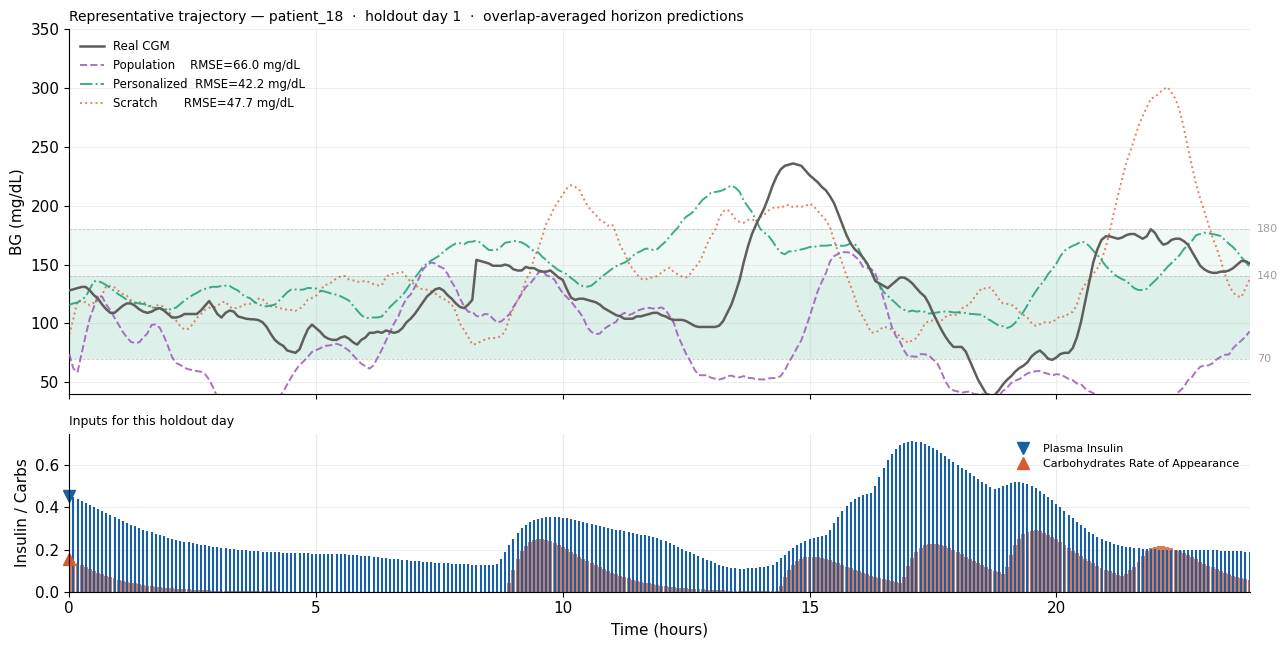

In [48]:
# ── Population decoder: reload pretrained weights (before any personalization) ─
decoder_pop = load_model(PRETRAINED, compile=False)
# ── Select a 1-day display window from the holdout ───────────────────────────
TRAJ_DAY  = 0
day_start = TRAJ_DAY * SAMPLES_PER_DAY
day_end   = min(day_start + SAMPLES_PER_DAY, holdout_ins.shape[0])
ho_ins  = holdout_ins[day_start:day_end]
ho_carb = holdout_carbs[day_start:day_end]
# ── Real BG: raw df values aligned to the holdout window ─────────────────────
holdout_offset = len(df) - HOLDOUT_DAYS * SAMPLES_PER_DAY
real_start     = holdout_offset + day_start
real_end       = holdout_offset + day_end
G_real_day     = df["BG"].values[real_start:real_end].astype(float)
t_hours        = np.arange(len(G_real_day)) * 5 / 60
# ── Generate overlap-averaged trajectories ────────────────────────────────────
G_pop_traj  = moving_avg_trajectory(decoder_pop,     ho_ins, ho_carb, scalers["bg"], seed=None)
G_pers_traj = moving_avg_trajectory(decoder,          ho_ins, ho_carb, scalers["bg"], seed=None)
G_scr_traj  = moving_avg_trajectory(decoder_scratch,  ho_ins, ho_carb, scalers["bg"], seed=None)
# Trim everything to real BG length for aligned plotting
n = len(G_real_day)
G_pop_traj  = G_pop_traj[:n]
G_pers_traj = G_pers_traj[:n]
G_scr_traj  = G_scr_traj[:n]
t_hours     = t_hours[:n]
ins_flat    = np.asarray(ho_ins).reshape(-1)[:n]
carb_flat   = np.asarray(ho_carb).reshape(-1)[:n]
# ── RMSE (overall, per model) ──────────────────────────────────────────────────
def rmse(a, b):
    mask = ~(np.isnan(a) | np.isnan(b))
    return np.sqrt(np.mean((a[mask] - b[mask]) ** 2))

rmse_pop  = rmse(G_pop_traj,  G_real_day)
rmse_pers = rmse(G_pers_traj, G_real_day)
rmse_scr  = rmse(G_scr_traj,  G_real_day)
# ── Detect onsets (0 → nonzero transitions) for the input flags ───────────────
ins_onset  = np.where((ins_flat  > 0) & (np.r_[0, ins_flat[:-1]]  <= 0))[0]
carb_onset = np.where((carb_flat > 0) & (np.r_[0, carb_flat[:-1]] <= 0))[0]
# ── Plot ──────────────────────────────────────────────────────────────────────
COL_T = {
    "Real CGM":     "#5F5E5A",
    "Population":   "#9B59B6",
    "Personalized": "#1D9E75",
    "Scratch":      "#D85A30",
    "Insulin":      "#185FA5",
    "Carbs":        "#D85A30",
}
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 6.6),
                               gridspec_kw={"height_ratios": [3, 1.3]}, sharex=True)

# — Trajectory panel —
ax.plot(t_hours, G_real_day,  color=COL_T["Real CGM"],     lw=1.8,          label="Real CGM",                             zorder=4)
ax.plot(t_hours, G_pop_traj,  color=COL_T["Population"],   lw=1.4, ls="--", label=f"Population    RMSE={rmse_pop:.1f} mg/dL",  zorder=3, alpha=.85)
ax.plot(t_hours, G_pers_traj, color=COL_T["Personalized"], lw=1.4, ls="-.", label=f"Personalized  RMSE={rmse_pers:.1f} mg/dL", zorder=3, alpha=.85)
ax.plot(t_hours, G_scr_traj,  color=COL_T["Scratch"],      lw=1.4, ls=":",  label=f"Scratch       RMSE={rmse_scr:.1f} mg/dL",  zorder=2, alpha=.75)
ax.axhspan(70, 180, color="#1D9E75", alpha=.06, lw=0)
ax.axhspan(70, 140, color="#1D9E75", alpha=.09, lw=0)
for q, lbl in [(70, "70"), (140, "140"), (180, "180")]:
    ax.axhline(q, color="#5F5E5A", lw=.6, ls="--", alpha=.3)
    ax.text(t_hours[-1] + 0.15, q, lbl, va="center", fontsize=8, color="#5F5E5A", alpha=.6)
# thin guide lines linking each input onset to the BG response above it
for t in t_hours[ins_onset]:
    ax.axvline(t, color=COL_T["Insulin"], lw=.7, ls=":", alpha=.4)
for t in t_hours[carb_onset]:
    ax.axvline(t, color=COL_T["Carbs"], lw=.7, ls=":", alpha=.4)
ax.set_xlim(t_hours[0], t_hours[-1]); ax.set_ylim(40, 350)
ax.set_ylabel("BG (mg/dL)")
ax.set_title(
    f"Representative trajectory — {PATIENT_ID}  ·  "
    f"holdout day {TRAJ_DAY + 1}  ·  overlap-averaged horizon predictions",
    loc="left", fontsize=10,
)
ax.legend(frameon=False, fontsize=8.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=.2)

# — Insulin / carbs input panel —
ax2.stem(t_hours, ins_flat, linefmt=COL_T["Insulin"], markerfmt=" ", basefmt=" ")
ax2.bar(t_hours, carb_flat, width=0.08, color=COL_T["Carbs"], alpha=.8)
for t in t_hours[ins_onset]:
    ax2.axvline(t, color=COL_T["Insulin"], lw=.7, ls=":", alpha=.4)
for t in t_hours[carb_onset]:
    ax2.axvline(t, color=COL_T["Carbs"], lw=.7, ls=":", alpha=.4)
ax2.plot(t_hours[ins_onset],  ins_flat[ins_onset],  marker="v", ls="none",
         color=COL_T["Insulin"], markersize=8, label="Plasma Insulin", clip_on=False)
ax2.plot(t_hours[carb_onset], carb_flat[carb_onset], marker="^", ls="none",
         color=COL_T["Carbs"], markersize=8, label="Carbohydrates Rate of Appearance", clip_on=False)
ax2.set_xlim(t_hours[0], t_hours[-1])
ax2.set_xlabel("Time (hours)"); ax2.set_ylabel("Insulin / Carbs")
ax2.set_title("Inputs for this holdout day", loc="left", fontsize=9)
ax2.legend(frameon=False, fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", alpha=.2)

plt.tight_layout()
plt.savefig(f"trajectory_{PATIENT_ID}.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 6 · Counterfactual therapy effects

Hold the insulin/carb context fixed, draw the latent **many** times per condition, then perturb therapy and read the shift in the hypoglycemia-risk distribution. By the decoder's sign constraint, insulin ↑ must move BG down and carbs ↑ must move it up — if a perturbation goes the wrong way, the monotonicity constraint is broken.

This section is a **hypothetical**, not a search for hidden risk in the data: we don't scan the holdout for a moment where something already went wrong. Instead we pick an ordinary window where the patient looks fine, pose a "what if" — *what if tonight's insulin dose were higher than planned?* — and use the personalized twin to test the consequences, and the fix, safely, before anything happens for real.

**Workflow:**
1. **Pick a window** — an ordinary moment where the patient's current BG is safe
2. **Baseline** — confirm risk under the real, as-planned dose (expected low)
3. **Hypothetical** — apply a dosing error (higher insulin), show risk rises
4. **Intervene Step 1** — reduce the elevated dose by 20%, re-evaluate
5. **Intervene Step 2** — if still at risk, add carbohydrate rescue (+15 g)
6. **Compare** — summary panel across all four conditions


#### 6.1 · Hypo detection functions

Clinical definition: hypoglycemia = BG < 70 mg/dL for 3 consecutive samples (≈ 15 minutes at 5-min sampling).


In [39]:
# ---- BLANK 8 ----
# Complete the consecutive-sample detection logic inside has_hypo().
# Hint: for a 1-D boolean array `below`, sliding sum over k elements:
#   np.convolve(below.astype(int), np.ones(k), mode='valid')
#   → any element == k means k consecutive True values

def has_hypo(g, threshold=70, min_consecutive=3):
    """
    Return True if trajectory g (1-D, mg/dL) contains at least
    `min_consecutive` consecutive samples below `threshold`.
    """
    below = (g < threshold).astype(int)
    runs = np.convolve(below, np.ones(min_consecutive, dtype=int), mode="valid")   # hint: np.convolve(...)
    return bool(np.any(runs == min_consecutive))                                   # hint: any run == min_consecutive?

def hypo_risk(draws, threshold=70, min_consecutive=3):
    """
    Fraction of draws (n_draws, n, H) containing at least one hypo episode.
    Flattens each draw to a 1-D BG sequence before checking.
    """
    n_draws = draws.shape[0]
    hits = sum(
        has_hypo(draws[i].reshape(-1), threshold, min_consecutive)
        for i in range(n_draws)
    )
    return hits / n_draws


#### 6.2 · Pick a window

We pick an ordinary window from the holdout where the patient's current BG is safe — this just sets the scene ("the patient looks fine right now, and is about to receive their scheduled insulin"). It is **not** a search for risk; risk only enters in the next two steps.


In [40]:
WIN_SIZE = 15   # 15 samples = 75 min of context
SAFE_BG  = 90   # mg/dL — just sets the scene: patient looks fine right now

# Pick the first ordinary window where the patient's current BG is safe.
n_windows = (len(holdout_ins) - WIN_SIZE) // WIN_SIZE
WINDOW_IDX = next(
    w * WIN_SIZE for w in range(n_windows)
    if to_mgdl(holdout_bg[w*WIN_SIZE : w*WIN_SIZE + WIN_SIZE], scalers["bg"]).mean() >= SAFE_BG
)

s, e = WINDOW_IDX, WINDOW_IDX + WIN_SIZE
risk_ins   = holdout_ins  [s:e]
risk_carbs = holdout_carbs[s:e]
risk_bg    = to_mgdl(holdout_bg[s:e], scalers["bg"])

print(f"Selected window: samples {s}–{e}")
print(f"  Current BG (real): {risk_bg.mean():.1f} mg/dL  (safe)")


Selected window: samples 0–15
  Current BG (real): 128.2 mg/dL  (safe)


#### 6.3 · Baseline — risk under the real, as-planned dose

Evaluate the *actual* scheduled therapy in the selected window — no hypothetical yet. This is expected to be low risk; it's the "before" picture the rest of the section compares against.

> Every risk evaluation from here on uses `base_seed=0`, so all conditions draw the *same* latent samples. That isolates the effect of each therapy change from sampling noise — see Discussion Q2.


In [55]:
N_DRAWS = 10

pooled_base, perdraw_base, draws_base = simulate_mc(
    decoder, risk_ins, risk_carbs, scalers["bg"], n_draws=N_DRAWS, base_seed=0
)
risk_base = hypo_risk(draws_base)

print(f"\n{'─'*50}")
print(f"  BASELINE (real, as-planned therapy)")
print(f"  Hypo risk:   {risk_base*100:.0f}%  ({int(risk_base*N_DRAWS)}/{N_DRAWS} draws)")
print(f"{'─'*50}")
print("  This is the 'before' picture — the plan as scheduled.")



──────────────────────────────────────────────────
  BASELINE (real, as-planned therapy)
  Hypo risk:   0%  (0/10 draws)
──────────────────────────────────────────────────
  This is the 'before' picture — the plan as scheduled.


<!-- QUESTION 3 — before cell 32 (§6.4, stress test) -->
<div style="border-left:4px solid #D85A30;background:#FDF0EA;padding:14px 18px;border-radius:0 8px 8px 0">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:6px">
<span style="background:#D85A30;color:#FDF0EA;font-size:11px;font-weight:500;letter-spacing:.04em;padding:3px 9px;border-radius:20px">PREDICT</span>
<span style="color:#5a2a12;font-size:15px;font-weight:500">Would the population model already get this right?</span>
<span style="margin-left:auto;color:#D85A30;font-size:12px">Notebook B · counterfactual</span>
</div>
<p style="margin:6px 0 0;color:#6b3418;font-size:13.5px;line-height:1.6">The sign constraint — more insulin only ever pushes BG down — is baked into the decoder's architecture, not learned from this patient. That means even the <i>unpersonalized population model</i> would get the <b>direction</b> of this stress test right.</p>
<p style="margin:8px 0 0;color:#6b3418;font-size:13.5px;line-height:1.6">So if direction alone isn't where personalization earns its keep, it has to be in the <b>size</b> of the response — and that's exactly what's not guaranteed. The baseline hypo risk under the real, as-planned dose is printed just above (look for <code style="background:#f2ddd0;padding:1px 5px;border-radius:4px">risk_base</code>).</p>
<p style="margin:8px 0 0;color:#D85A30;font-size:13.5px"><b style="font-weight:500">Your bet:</b> with insulin scaled by <code style="background:#f2ddd0;padding:1px 5px;border-radius:4px">STRESS_FACTOR</code>, give a rough number for the new risk — does it double? Triple? Cross 50%? Then run the cell and check.</p>
</div>

#### 6.4 · Hypothetical — what if the dose were too high?

We now pose the question this section is built to answer: what if, for whatever reason, tonight's insulin dose was higher than planned? By the decoder's sign constraint, more insulin can only push BG down — so risk should rise here, regardless of which patient or window we picked. *How much* it rises is this patient's own physiology — the personalization argument, made concrete.


In [56]:
STRESS_FACTOR = 1.4   # a hypothetical dosing error — 50% more insulin than planned

ins_stress = risk_ins * STRESS_FACTOR

pooled_stress, perdraw_stress, draws_stress = simulate_mc(
    decoder, ins_stress, risk_carbs, scalers["bg"], n_draws=N_DRAWS, base_seed=0
)
risk_stress = hypo_risk(draws_stress)

delta = risk_stress - risk_base
print(f"\n{'─'*50}")
print(f"  HYPOTHETICAL  Insulin × {STRESS_FACTOR}")
print(f"  Hypo risk: {risk_base*100:.0f}% → {risk_stress*100:.0f}%  "
      f"({'↑' if delta > 0 else '↓'} {abs(delta)*100:.0f} pp)")
print(f"{'─'*50}")
if risk_stress >= 0.25:
    print("  ⚠  Risk ≥ 25% under the hypothetical dose — intervention recommended.")
else:
    print("  This patient's risk stayed low even under a 50% dosing error —")
    print("  a real result, and a useful one: not every error is equally dangerous.")



──────────────────────────────────────────────────
  HYPOTHETICAL  Insulin × 1.4
  Hypo risk: 0% → 50%  (↑ 50 pp)
──────────────────────────────────────────────────
  ⚠  Risk ≥ 25% under the hypothetical dose — intervention recommended.


#### 6.5 · Step 1 — reduce the elevated dose by 20%

First-line correction: partially walk back the elevated dose.


In [52]:
# ---- BLANK 9 ----
ins_reduced = ins_stress * 0.8   # hint: a 20% reduction keeps 80% of the (elevated) dose

pooled_ins, perdraw_ins, draws_ins = simulate_mc(
    decoder, ins_reduced, risk_carbs, scalers["bg"], n_draws=N_DRAWS, base_seed=0
)
risk_ins_red = hypo_risk(draws_ins)

delta = risk_ins_red - risk_stress
print(f"\n{'─'*50}")
print(f"  STEP 1  Insulin −20% (from the elevated dose)")
print(f"  Hypo risk: {risk_stress*100:.0f}% → {risk_ins_red*100:.0f}%  "
      f"({'↓' if delta < 0 else '↑'} {abs(delta)*100:.0f} pp)")
print(f"{'─'*50}")
if risk_ins_red < 0.25:
    print("  ✓  Risk resolved — no further intervention needed.")
    pooled_combo  = pooled_ins
    perdraw_combo = perdraw_ins
    draws_combo   = draws_ins
    risk_combo    = risk_ins_red
    STEP2_LABEL   = "Insulin −20%\n(Step 2 not needed)"
else:
    print("  ⚠  Risk still ≥ 25% — proceed to carbohydrate rescue (Step 2).")
    STEP2_LABEL   = "Insulin −20% + Carbs"



──────────────────────────────────────────────────
  STEP 1  Insulin −20% (from the elevated dose)
  Hypo risk: 50% → 0%  (↓ 50 pp)
──────────────────────────────────────────────────
  ✓  Risk resolved — no further intervention needed.


#### 6.6 · Step 2 — add carbohydrate rescue (+15 g)

Only runs if Step 1 left risk above the 25% threshold.


In [53]:
if risk_ins_red >= 0.25:
    CARB_RESCUE_G = 15.0
    carbs_rescue  = risk_carbs.copy()
    carbs_rescue[:3] += CARB_RESCUE_G / 3.0   # spread over ≈15 min

    pooled_combo, perdraw_combo, draws_combo = simulate_mc(
        decoder, ins_reduced, carbs_rescue, scalers["bg"], n_draws=N_DRAWS, base_seed=0
    )
    risk_combo = hypo_risk(draws_combo)

    delta2 = risk_combo - risk_ins_red
    print(f"\n{'─'*50}")
    print(f"  STEP 2  Insulin −20%  +  Carbs +{CARB_RESCUE_G:.0f} g")
    print(f"  Hypo risk: {risk_ins_red*100:.0f}% → {risk_combo*100:.0f}%  "
          f"({'↓' if delta2 < 0 else '↑'} {abs(delta2)*100:.0f} pp)")
    print(f"{'─'*50}")
    if risk_combo < 0.25:
        print("  ✓  Risk resolved.")
    else:
        print("  ⚠  Risk persists — consider further escalation.")
else:
    print("  Step 2 skipped — risk already resolved at Step 1.")


  Step 2 skipped — risk already resolved at Step 1.


#### 6.7 · Summary panel


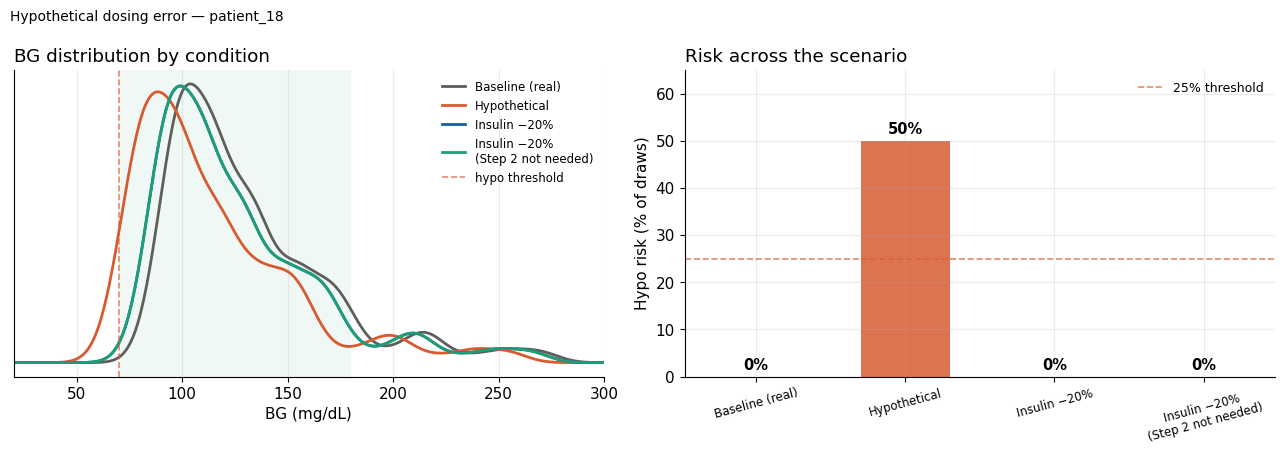

In [54]:
from scipy.stats import gaussian_kde

COND_COL = {
    "Baseline (real)": "#5F5E5A",
    "Hypothetical":     "#D85A30",
    "Insulin −20%":     "#185FA5",
    STEP2_LABEL:        "#1D9E75",
}

all_pooled = {
    "Baseline (real)": pooled_base,
    "Hypothetical":     pooled_stress,
    "Insulin −20%":     pooled_ins,
    STEP2_LABEL:        pooled_combo,
}
all_risks = {
    "Baseline (real)": risk_base,
    "Hypothetical":     risk_stress,
    "Insulin −20%":     risk_ins_red,
    STEP2_LABEL:        risk_combo,
}

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "font.size": 11,
})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))
grid = np.linspace(20, 300, 400)

for nm, d in all_pooled.items():
    axL.plot(grid, gaussian_kde(d.reshape(-1))(grid),
             color=COND_COL[nm], lw=2, label=nm)
axL.axvspan(70, 180, color="#1D9E75", alpha=.07, lw=0)
axL.axvline(70, color="#D85A30", lw=1.2, ls="--", alpha=.7, label="hypo threshold")
axL.set_xlim(20, 300); axL.set_yticks([])
axL.set_xlabel("BG (mg/dL)")
axL.set_title("BG distribution by condition", loc="left")
axL.legend(frameon=False, fontsize=8.5)

names  = list(all_risks.keys())
risks  = [all_risks[n] * 100 for n in names]
colors = [COND_COL[n] for n in names]
bars   = axR.bar(names, risks, color=colors, edgecolor="none", alpha=.85, width=.6)
axR.axhline(25, color="#D85A30", lw=1.2, ls="--", alpha=.7, label="25% threshold")
for bar, val in zip(bars, risks):
    axR.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.8,
             f"{val:.0f}%",
             ha="center", va="bottom", fontsize=10.5, fontweight="bold")
axR.set_ylim(0, max(max(risks) * 1.3, 35))
axR.set_ylabel("Hypo risk (% of draws)")
axR.set_title("Risk across the scenario", loc="left")
axR.tick_params(axis="x", labelrotation=15, labelsize=8.5)
axR.legend(frameon=False, fontsize=9)

fig.suptitle(f"Hypothetical dosing error — {PATIENT_ID}", x=.01, ha="left", fontsize=10)
plt.tight_layout()
plt.show()


### Reading the results

**Baseline (6.3):** risk under the real, scheduled therapy — the "before" picture, expected to be low.

**Hypothetical (6.4):** the same window, but with a simulated dosing error. The *direction* of the shift (risk up) is guaranteed by the sign constraint; the *size* of the shift is this patient's own physiology — exactly what a population model can't tell you.

**BG distribution (left):** mass to the left of 70 mg/dL drives hypo risk. Watch how each condition shifts the distribution.

**Risk bar chart (right):** hypo probability per condition. The 25% dashed line is the intervention threshold.

**Key questions for discussion:**
- How large was the risk increase under the hypothetical dosing error, and did Step 1 alone resolve it?
- Try a larger `STRESS_FACTOR` (e.g. 2.0) — does the same 20% reduction still work?
- Change `PATIENT_ID` and re-run — does the same intervention work for a different patient? This is the personalization argument made concrete.


### Discussion

1. How large is the pretraining advantage (Δ W1 = W1(scratch) − W1(personalized))? Look at the glucodensity/ECDF plots from Section 4 — does the improvement show up more in the hypo tail, the centre, or the hyper tail?
2. The counterfactual uses the *same* latent draws across conditions. Why does that matter for isolating the therapy effect?
3. **Break the constraint:** go back to Notebook A, flip Blank 3 so the insulin weight is positive, retrain, and rerun this cell. What happens to the `Insulin +20%` direction — and why is that clinically dangerous?